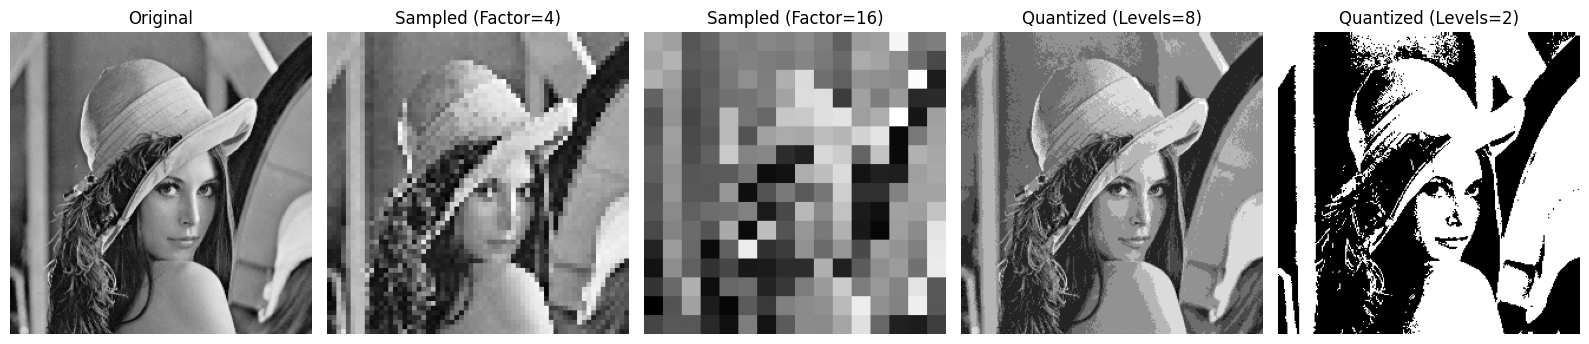

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the downsampling function
def sample_image(image, factor):
    height, width = image.shape[:2]
    # Resize image to a smaller resolution using Nearest Neighbor interpolation
    sampled = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    # Scale back to original resolution to visually highlight pixelation
    return cv2.resize(sampled, (width, height), interpolation=cv2.INTER_NEAREST)

# Define the quantization function
def quantize_image(image, levels):
    # Reduce the total number of intensity levels
    interval = 256 // levels
    quantized = np.floor(image / interval) * interval
    return quantized.astype(np.uint8)

# Read the grayscale image using the verified path
image_path = 'images/lena_gray_256.tif'
original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Verify that the image is loaded properly
if original is None:
    raise FileNotFoundError(f"Could not open image at {image_path}")

# Apply varying sampling factors
sampled_factor_4 = sample_image(original, factor=4)
sampled_factor_16 = sample_image(original, factor=16)

# Apply varying quantization levels
quantized_level_8 = quantize_image(original, levels=8)
quantized_level_2 = quantize_image(original, levels=2)

# Display comparative results
titles = [
    'Original', 
    'Sampled (Factor=4)', 
    'Sampled (Factor=16)', 
    'Quantized (Levels=8)', 
    'Quantized (Levels=2)'
]
images = [
    original, 
    sampled_factor_4, 
    sampled_factor_16, 
    quantized_level_8, 
    quantized_level_2
]

plt.figure(figsize=(16, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

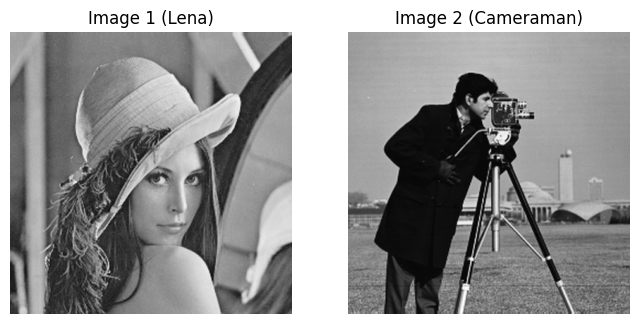

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load both grayscale images
img1 = Image.open('images/lena_gray_256.tif').convert('L')
img2 = Image.open('images/cameraman.tif').convert('L')

# Resize both images to equal dimensions (400x400)
target_size = (400, 400)
img1 = img1.resize(target_size, Image.Resampling.LANCZOS)
img2 = img2.resize(target_size, Image.Resampling.LANCZOS)

# Convert PIL images to NumPy arrays
im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

# Display both base images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(im1arr, cmap='gray')
plt.title('Image 1 (Lena)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im2arr, cmap='gray')
plt.title('Image 2 (Cameraman)')
plt.axis('off')
plt.show()

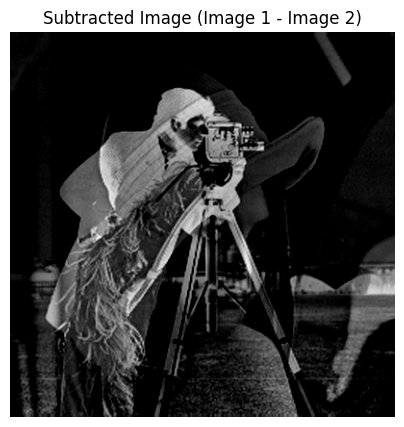

In [5]:
# Subtract Image 2 from Image 1 using saturation arithmetic (avoids underflow below 0)
subtraction_result = cv2.subtract(im1arr, im2arr)

# Display subtracted result
plt.figure(figsize=(5, 5))
plt.imshow(subtraction_result, cmap='gray')
plt.title('Subtracted Image (Image 1 - Image 2)')
plt.axis('off')
plt.show()

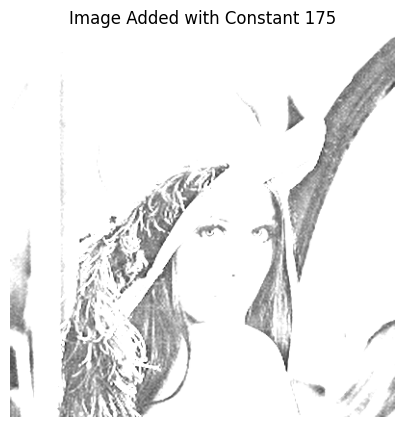

In [6]:
# Add scalar value 175 using saturation arithmetic (caps values at 255 to prevent overflow)
added_constant_result = cv2.add(im1arr, 175)

# Display addition result
plt.figure(figsize=(5, 5))
plt.imshow(added_constant_result, cmap='gray')
plt.title('Image Added with Constant 175')
plt.axis('off')
plt.show()

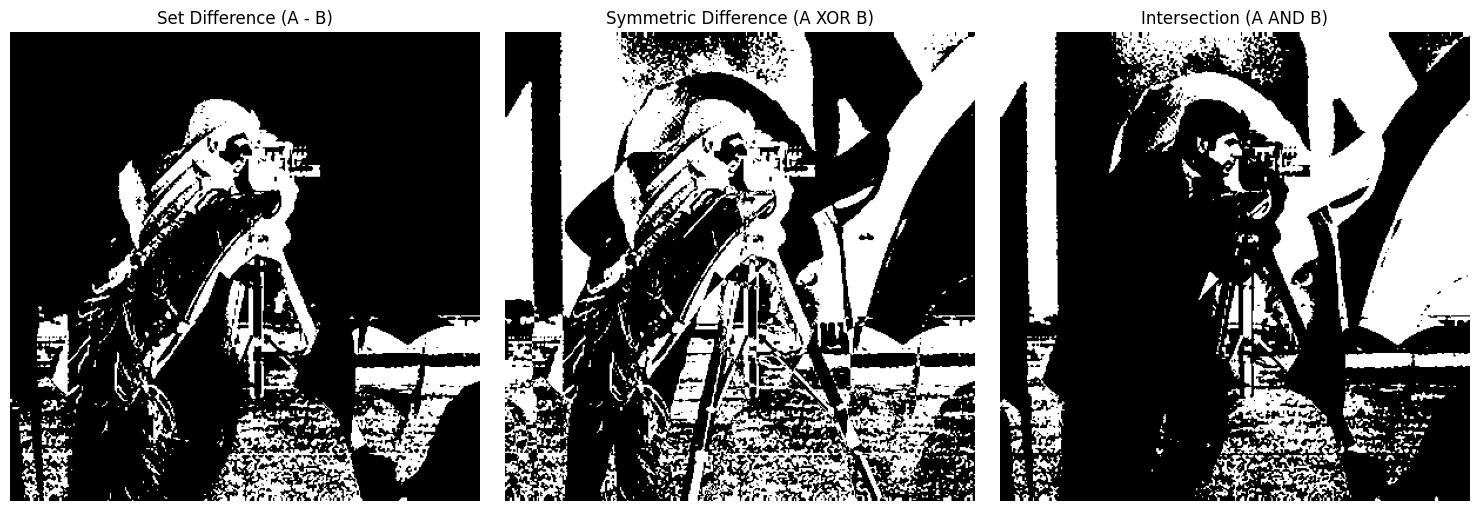

In [7]:
# Apply binary thresholding (T=128) to treat images as discrete sets
_, bin1 = cv2.threshold(im1arr, 128, 255, cv2.THRESH_BINARY)
_, bin2 = cv2.threshold(im2arr, 128, 255, cv2.THRESH_BINARY)

# 1. Set Difference (A \ B = A AND NOT B)
set_difference = cv2.bitwise_and(bin1, cv2.bitwise_not(bin2))

# 2. Symmetric Difference (A XOR B)
symmetric_difference = cv2.bitwise_xor(bin1, bin2)

# 3. Set Intersection (A AND B)
intersection_result = cv2.bitwise_and(bin1, bin2)

# Display all set operation outputs
titles = ['Set Difference (A - B)', 'Symmetric Difference (A XOR B)', 'Intersection (A AND B)']
results = [set_difference, symmetric_difference, intersection_result]

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(results[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()